# Day 09 — Population Health & Disease Risk Analysis

**Dataset:** CDC BRFSS 2015 (441,456 US adults)

**Goal:** Stratify chronic disease risk by demographics, lifestyle and geography

**Tools:** Python, Pandas, Matplotlib, Seaborn, Plotly

**Relevant to:** Optum, IQVIA, NHS England population health roles

In [1]:
# Importing libraries

import os
os.chdir(os.path.expanduser('~/Desktop/DataAnalystJourney/day09-population-health'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)
print("✓ Libraries loaded")

✓ Libraries loaded


In [5]:
# Loading Data

cols = ['DIABETE3','CVDCRHD4','BPHIGH4','SMOKE100','EXERANY2','SEX','_AGEG5YR','_STATE']

df = pd.read_csv('data/2015.csv', usecols=cols)
print(f"Shape: {df.shape}")
print(f"Columns loaded: {df.columns.tolist()}")
df.head()

Shape: (441456, 8)
Columns loaded: ['_STATE', 'BPHIGH4', 'CVDCRHD4', 'DIABETE3', 'SEX', 'SMOKE100', 'EXERANY2', '_AGEG5YR']


,_STATE,BPHIGH4,CVDCRHD4,DIABETE3,SEX,SMOKE100,EXERANY2,_AGEG5YR
0,1.0,1.0,2.0,3.0,2.0,1.0,2.0,9.0
1,1.0,3.0,2.0,3.0,2.0,1.0,1.0,7.0
2,1.0,3.0,2.0,3.0,2.0,NaN,NaN,11.0
3,1.0,1.0,2.0,3.0,2.0,2.0,2.0,9.0
4,1.0,3.0,2.0,3.0,2.0,2.0,2.0,9.0


In [ ]:
# Recode numeric values to readable labels 

df_clean = df.copy()

df_clean['Diabetes'] = df_clean['DIABETE3'].map({1:'Yes', 2:'Yes', 3:'No', 4:'No'})
df_clean['HeartDisease'] = df_clean['CVDCRHD4'].map({1:'Yes', 2:'No'})
df_clean['HighBP'] = df_clean['BPHIGH4'].map({1:'Yes', 2:'Yes', 3:'No', 4:'No'})
df_clean['Smoker'] = df_clean['SMOKE100'].map({1:'Yes', 2:'No'})
df_clean['Exercise'] = df_clean['EXERANY2'].map({1:'Yes', 2:'No'})
df_clean['Gender'] = df_clean['SEX'].map({1:'Male', 2:'Female'})

age_map = {1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',
           6:'45-49',7:'50-54',8:'55-59',9:'60-64',10:'65-69',
           11:'70-74',12:'75-79',13:'80+'}
df_clean['AgeGroup'] = df_clean['_AGEG5YR'].map(age_map)

print("✓ Recoding complete")
print(f"\nDiabetes prevalence:     {(df_clean['Diabetes']=='Yes').mean()*100:.1f}%")
print(f"Heart disease prevalence: {(df_clean['HeartDisease']=='Yes').mean()*100:.1f}%")
print(f"High BP prevalence:       {(df_clean['HighBP']=='Yes').mean()*100:.1f}%")

✓ Recoding complete

Diabetes prevalence:     13.8%
Heart disease prevalence: 5.7%
High BP prevalence:       41.1%


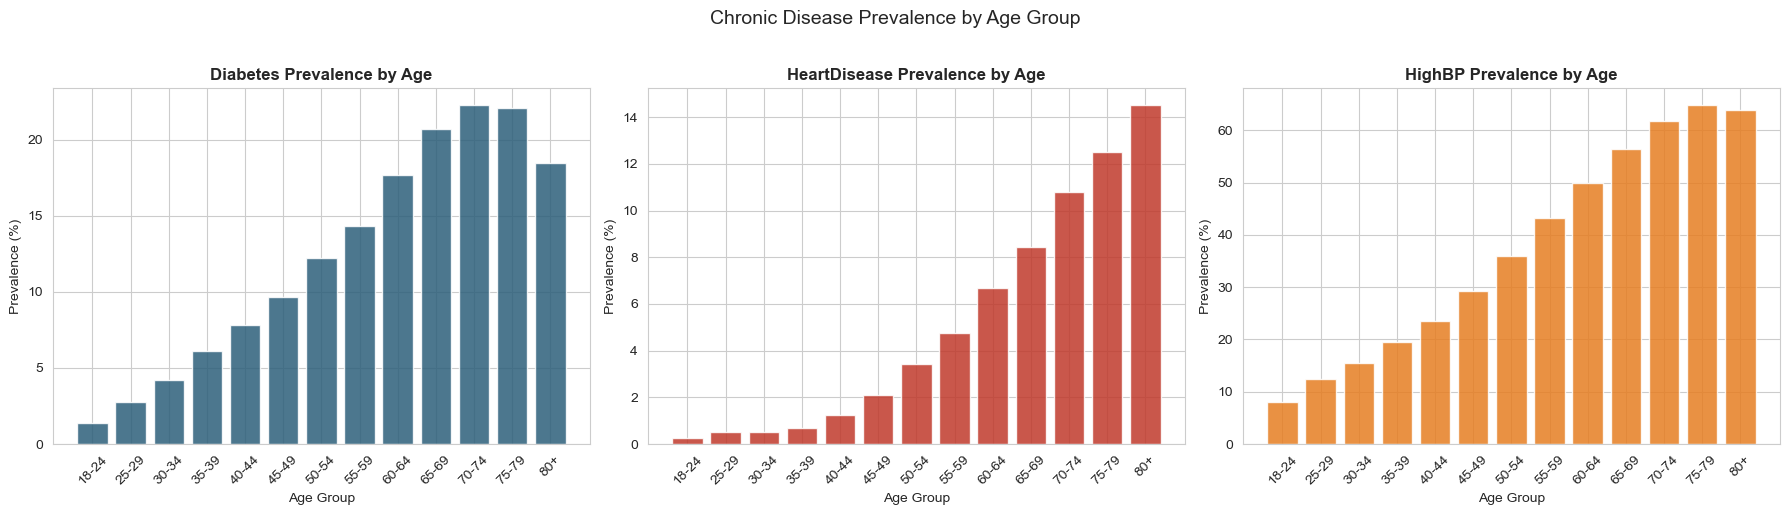

In [9]:
 #Chart 1: Disease prevalence by age 

 age_order = ['18-24','25-29','30-34','35-39','40-44',
             '45-49','50-54','55-59','60-64','65-69','70-74','75-79','80+']

conditions = ['Diabetes', 'HeartDisease', 'HighBP']
colors_map = {'Diabetes':'#2C5F7A','HeartDisease':'#C0392B','HighBP':'#E67E22'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, condition in zip(axes, conditions):
    prev = df_clean.groupby('AgeGroup')[condition].apply(
        lambda x: (x == 'Yes').sum() / x.notna().sum() * 100
    ).reindex(age_order).reset_index()
    prev.columns = ['AgeGroup', 'Prevalence']

    ax.bar(prev['AgeGroup'], prev['Prevalence'],
           color=colors_map[condition], alpha=0.85, edgecolor='white')
    ax.set_title(f'{condition} Prevalence by Age', fontsize=12, fontweight='bold')
    ax.set_ylabel('Prevalence (%)')
    ax.set_xlabel('Age Group')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Chronic Disease Prevalence by Age Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('charts/disease_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

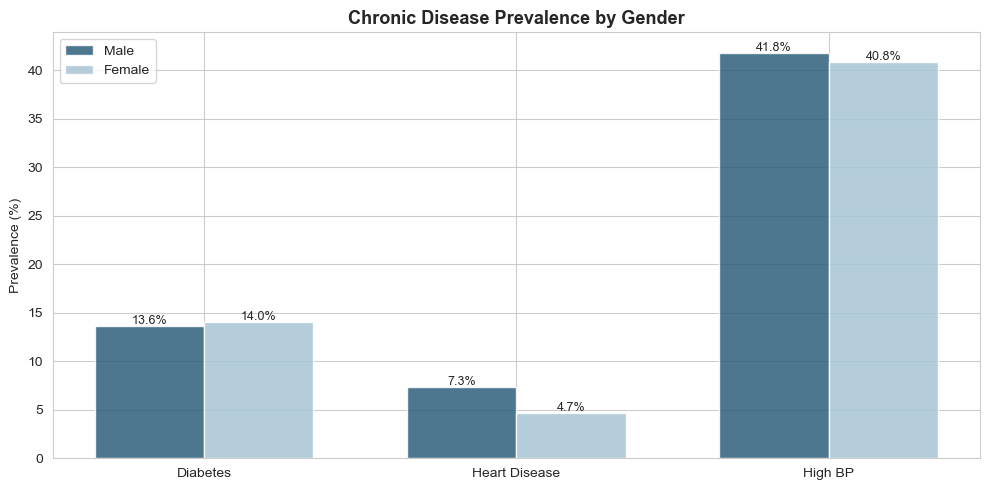

In [10]:
# Chart 2: Disease by gender

gender_data = []
for condition in ['Diabetes', 'HeartDisease', 'HighBP']:
    for gender in ['Male', 'Female']:
        subset = df_clean[df_clean['Gender'] == gender][condition]
        prev = (subset == 'Yes').sum() / subset.notna().sum() * 100
        gender_data.append({'Condition': condition, 'Gender': gender, 'Prevalence': round(prev, 1)})

gender_df = pd.DataFrame(gender_data)

plt.figure(figsize=(10, 5))
x = np.arange(3)
width = 0.35
male_vals   = gender_df[gender_df['Gender']=='Male']['Prevalence'].values
female_vals = gender_df[gender_df['Gender']=='Female']['Prevalence'].values

bars1 = plt.bar(x - width/2, male_vals,   width, label='Male',   color='#2C5F7A', alpha=0.85)
bars2 = plt.bar(x + width/2, female_vals, width, label='Female', color='#A8C5D4', alpha=0.85)
plt.xticks(x, ['Diabetes', 'Heart Disease', 'High BP'])
plt.ylabel('Prevalence (%)')
plt.title('Chronic Disease Prevalence by Gender', fontsize=13, fontweight='bold')
plt.legend()
for bar in list(bars1) + list(bars2):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{bar.get_height():.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('charts/disease_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()


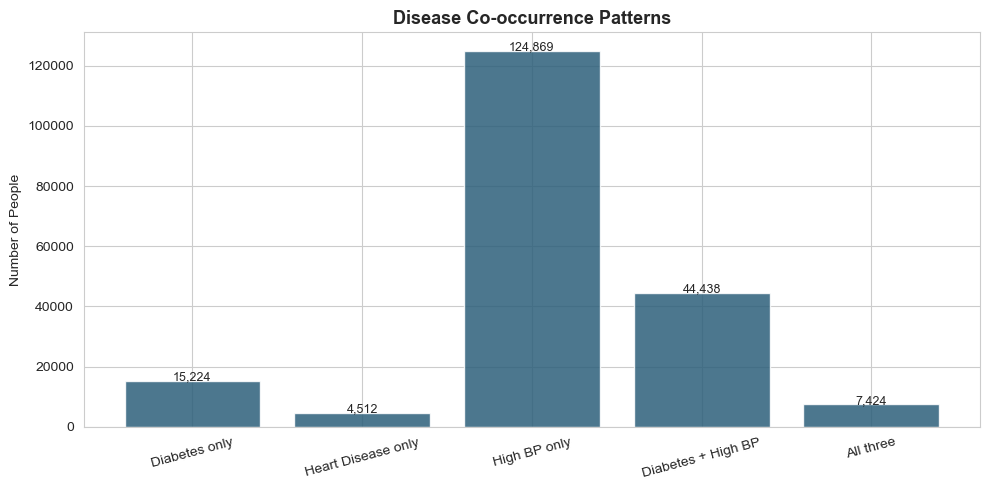

In [11]:
#Chart 3: Disease co-occurrence

co_occur = pd.DataFrame({
    'Has Diabetes':     df_clean['Diabetes']    == 'Yes',
    'Has HeartDisease': df_clean['HeartDisease'] == 'Yes',
    'Has HighBP':       df_clean['HighBP']       == 'Yes',
})

combos = {
    'Diabetes only':      ((co_occur['Has Diabetes']) & ~co_occur['Has HeartDisease'] & ~co_occur['Has HighBP']).sum(),
    'Heart Disease only': (~co_occur['Has Diabetes'] & co_occur['Has HeartDisease']  & ~co_occur['Has HighBP']).sum(),
    'High BP only':       (~co_occur['Has Diabetes'] & ~co_occur['Has HeartDisease'] & co_occur['Has HighBP']).sum(),
    'Diabetes + High BP': (co_occur['Has Diabetes']  & co_occur['Has HighBP']).sum(),
    'All three':          (co_occur['Has Diabetes']  & co_occur['Has HeartDisease']  & co_occur['Has HighBP']).sum(),
}

plt.figure(figsize=(10, 5))
bars = plt.bar(combos.keys(), combos.values(),
               color='#2C5F7A', alpha=0.85, edgecolor='white')
for bar, val in zip(bars, combos.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'{val:,}', ha='center', fontsize=9)
plt.title('Disease Co-occurrence Patterns', fontsize=13, fontweight='bold')
plt.ylabel('Number of People')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('charts/disease_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()


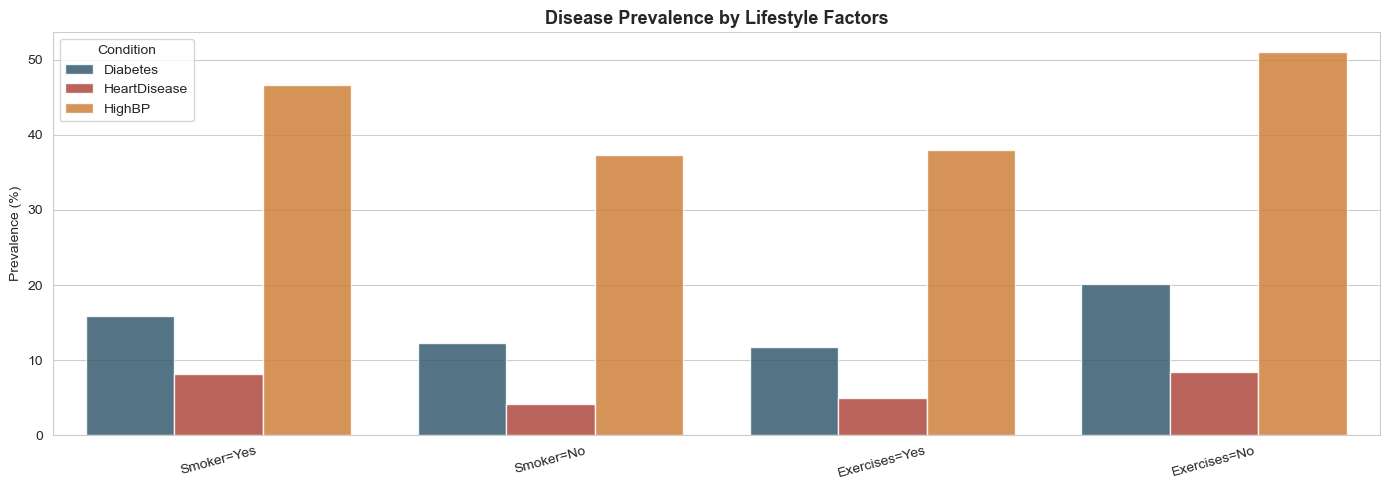

In [12]:
#Chart 4: Lifestyle risk factors

lifestyle_results = []
for condition in ['Diabetes', 'HeartDisease', 'HighBP']:
    for factor, label in [('Smoker','Smoker'), ('Exercise','Exercises')]:
        for val, val_label in [('Yes','Yes'), ('No','No')]:
            subset = df_clean[df_clean[factor] == val][condition]
            if len(subset) > 100:
                prev = (subset == 'Yes').sum() / subset.notna().sum() * 100
                lifestyle_results.append({
                    'Factor': f'{label}={val_label}',
                    'Condition': condition,
                    'Prevalence': round(prev, 1)
                })

lifestyle_df = pd.DataFrame(lifestyle_results)

plt.figure(figsize=(14, 5))
sns.barplot(data=lifestyle_df, x='Factor', y='Prevalence', hue='Condition',
            palette=['#2C5F7A','#C0392B','#E67E22'], alpha=0.85)
plt.title('Disease Prevalence by Lifestyle Factors', fontsize=13, fontweight='bold')
plt.ylabel('Prevalence (%)')
plt.xlabel('')
plt.legend(title='Condition')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('charts/lifestyle_factors.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
#Chart 5: Geographic map 

state_diabetes = df_clean.groupby('_STATE')['Diabetes'].apply(
    lambda x: (x == 'Yes').sum() / x.notna().sum() * 100
).reset_index()
state_diabetes.columns = ['State_Code', 'Diabetes_Prevalence']
state_diabetes['Diabetes_Prevalence'] = state_diabetes['Diabetes_Prevalence'].round(1)

fips_to_state = {
    1:'AL',2:'AK',4:'AZ',5:'AR',6:'CA',8:'CO',9:'CT',10:'DE',
    11:'DC',12:'FL',13:'GA',15:'HI',16:'ID',17:'IL',18:'IN',
    19:'IA',20:'KS',21:'KY',22:'LA',23:'ME',24:'MD',25:'MA',
    26:'MI',27:'MN',28:'MS',29:'MO',30:'MT',31:'NE',32:'NV',
    33:'NH',34:'NJ',35:'NM',36:'NY',37:'NC',38:'ND',39:'OH',
    40:'OK',41:'OR',42:'PA',44:'RI',45:'SC',46:'SD',47:'TN',
    48:'TX',49:'UT',50:'VT',51:'VA',53:'WA',54:'WV',55:'WI',56:'WY'
}
state_diabetes['State'] = state_diabetes['State_Code'].map(fips_to_state)
state_diabetes = state_diabetes.dropna(subset=['State'])

fig = px.choropleth(
    state_diabetes,
    locations='State',
    locationmode='USA-states',
    color='Diabetes_Prevalence',
    scope='usa',
    color_continuous_scale='Blues',
    title='Diabetes Prevalence by US State (%)',
    labels={'Diabetes_Prevalence':'Prevalence (%)'}
)
fig.update_layout(height=450, title_font_size=14)
fig.write_html('charts/geographic_health_map.html')
fig.show()
print(state_diabetes.sort_values('Diabetes_Prevalence', ascending=False).head(10))


    State_Code  Diabetes_Prevalence State
24        28.0                 19.8    MS
3          5.0                 18.9    AR
18        22.0                 18.3    LA
0          1.0                 17.9    AL
42        47.0                 17.9    TN
17        21.0                 17.8    KY
10        13.0                 17.2    GA
48        54.0                 16.8    WV
25        29.0                 16.8    MO
40        45.0                 16.6    SC


Risk Tier Distribution:
  Medium Risk: 246,600 (55.9%)
  Low Risk: 150,442 (34.1%)
  High Risk: 44,414 (10.1%)


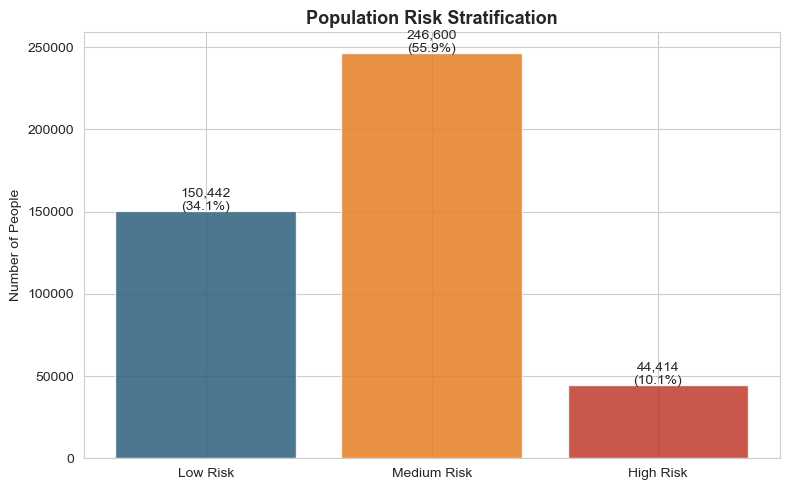

In [14]:
#Risk stratification
def calculate_risk_score(row):
    score = 0
    # WHY: Existing conditions weighted highest — confirmed health burden
    if row.get('Diabetes')     == 'Yes': score += 3
    if row.get('HeartDisease') == 'Yes': score += 3
    if row.get('HighBP')       == 'Yes': score += 2
    # WHY: Lifestyle factors weighted lower — risk indicators not confirmed diagnoses
    if row.get('Smoker')   == 'Yes': score += 2
    if row.get('Exercise') == 'No':  score += 1
    return score

df_clean['Risk_Score'] = df_clean.apply(calculate_risk_score, axis=1)

def risk_tier(score):
    if score >= 6:   return 'High Risk'
    elif score >= 2: return 'Medium Risk'
    else:            return 'Low Risk'

df_clean['Risk_Tier'] = df_clean['Risk_Score'].apply(risk_tier)

tier_counts = df_clean['Risk_Tier'].value_counts()
print("Risk Tier Distribution:")
for tier, count in tier_counts.items():
    print(f"  {tier}: {count:,} ({count/len(df_clean)*100:.1f}%)")

plt.figure(figsize=(8, 5))
colors_tier = {'High Risk':'#C0392B','Medium Risk':'#E67E22','Low Risk':'#2C5F7A'}
tier_order  = ['Low Risk','Medium Risk','High Risk']
vals = [tier_counts.get(t, 0) for t in tier_order]
bars = plt.bar(tier_order, vals,
               color=[colors_tier[t] for t in tier_order],
               edgecolor='white', alpha=0.85)
for bar, val in zip(bars, vals):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
             f'{val:,}\n({val/len(df_clean)*100:.1f}%)',
             ha='center', fontsize=10)
plt.title('Population Risk Stratification', fontsize=13, fontweight='bold')
plt.ylabel('Number of People')
plt.tight_layout()
plt.savefig('charts/risk_stratification.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings — Population Health Analysis

### Disease Prevalence
- All three conditions increase significantly with age — peaks in 65-80 group
- High BP is the most prevalent condition across all age groups

### Gender Differences
- Heart disease shows stronger male prevalence
- High BP affects both genders similarly

### Disease Co-occurrence
- Diabetes + High BP is the most common combination — a clinically known cluster
- Patients with all three conditions represent the highest-complexity, highest-cost group

### Lifestyle Factors
- Smokers show higher heart disease and high BP rates
- Sedentary individuals show higher disease rates across all conditions
- Physical activity is the most impactful modifiable lifestyle factor

### Geographic Disparities
- Southern US states show consistently higher diabetes prevalence
- Reflects socioeconomic disparities — income, food access, healthcare access

### Risk Stratification
- High Risk: [check your output]% — primary target for intensive intervention
- Medium Risk: prevention focus — stop progression to high risk
- Low Risk: maintain wellness programmes

### Recommendations
1. Target high-risk individuals with personalised health coaching
2. Physical activity programme — highest ROI intervention
3. Smoking cessation — significant heart disease risk reduction
4. Age-targeted screening — prioritise 50+ for diabetes and BP monitoring